<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_PROTOKEN_TOKEN_LEVEL_ATTRIBUTION_FOR_FEDERATED_LARGE_LANGUAGE_MODELS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Environment Setup
!pip install -q torch transformers matplotlib seaborn numpy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple

# Set seed and device
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Cell 2: Federated Model Setup (Client 0: Medical, Client 1: Math/Code)
print("Loading Base LLM (GPT-2) for Federated ProToken Evaluation...")

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Load Base Federated Model
fed_model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

# Simulate 2 Federated Clients with Domain Specialization
client_0_model = AutoModelForCausalLM.from_pretrained(model_name).to(device) # Medical
client_1_model = AutoModelForCausalLM.from_pretrained(model_name).to(device) # Math/Code

medical_data = ["patient diagnosis prescription dosage therapy symptoms clinic hospital"] * 10
math_data = ["equation derivative integral calculus matrix function algorithm compute"] * 10

def fine_tune_client(model, data_list, lr=3e-4):
    opt = AdamW(model.parameters(), lr=lr)
    model.train()
    inputs = tokenizer(data_list, return_tensors="pt", padding=True).to(device)
    for _ in range(10):
        opt.zero_grad()
        loss = model(inputs["input_ids"], labels=inputs["input_ids"]).loss
        loss.backward()
        opt.step()
    model.eval()

print("Fine-tuning Client 0 (Medical Domain)...")
fine_tune_client(client_0_model, medical_data)

print("Fine-tuning Client 1 (Math/Code Domain)...")
fine_tune_client(client_1_model, math_data)

# Perform FedAvg to update Federated Model
with torch.no_grad():
    for p_fed, p_c0, p_c1 in zip(fed_model.parameters(), client_0_model.parameters(), client_1_model.parameters()):
        p_fed.copy_(0.5 * p_c0 + 0.5 * p_c1)

print("Federated Aggregation Complete. Client models and Global FL model ready.")

Loading Base LLM (GPT-2) for Federated ProToken Evaluation...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Fine-tuning Client 0 (Medical Domain)...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Fine-tuning Client 1 (Math/Code Domain)...
Federated Aggregation Complete. Client models and Global FL model ready.


In [7]:
# Cell 3: ProToken Attribution Engine (Fixed Directional Alignment)
class ProTokenEngine:
    """
    Implements ProToken (Token-Level Attribution for Federated LLMs).
    Exploits late-layer signal concentration and gradient-based relevance
    to map generated tokens to client parameter updates.
    """
    def __init__(self, global_model, client_models, tokenizer, late_layer_idx=10):
        self.global_model = global_model
        self.client_models = client_models
        self.tokenizer = tokenizer
        self.late_layer_idx = late_layer_idx
        self.device = next(global_model.parameters()).device

        # Precompute Client Footprints at Late Transformer Layer
        self.client_deltas = self._compute_client_deltas()

    def _compute_client_deltas(self) -> List[torch.Tensor]:
        client_deltas = []
        global_layer = self.global_model.transformer.h[self.late_layer_idx].mlp.c_proj.weight

        for c_model in self.client_models:
            client_layer = c_model.transformer.h[self.late_layer_idx].mlp.c_proj.weight
            # The directional update the client applied
            delta = (client_layer - global_layer).detach().flatten()
            client_deltas.append(delta)
        return client_deltas

    def attribute_token(self, prompt_ids: torch.Tensor, target_token_id: int) -> Dict[str, float]:
        self.global_model.eval()
        self.global_model.zero_grad()

        # Forward Pass
        outputs = self.global_model(input_ids=prompt_ids)
        logits = outputs.logits[:, -1, :]
        target_logit = logits[0, target_token_id]

        # Backward Pass to get Logit-Gradient w.r.t Late Layer Weights
        target_logit.backward()

        # ProToken Insight: Gradient-based Relevance Weighting
        # The gradient shows how weights needed to change to produce this token
        weight_grad = self.global_model.transformer.h[self.late_layer_idx].mlp.c_proj.weight.grad
        relevance = weight_grad.detach().flatten()

        # Measure Cosine Similarity alignment with Client Parameter Deltas
        client_scores = []
        for c_delta in self.client_deltas:
            score = F.cosine_similarity(relevance.unsqueeze(0), c_delta.unsqueeze(0)).item()
            client_scores.append(score)

        # Softmax with temperature scaling to yield attribution probabilities
        scores_tensor = torch.tensor(client_scores)
        norm_scores = F.softmax(scores_tensor * 10, dim=0).tolist()

        return {"Client_0 (Medical)": norm_scores[0], "Client_1 (Math)": norm_scores[1]}

print("ProToken Engine initialized successfully.")

ProToken Engine initialized successfully.


In [8]:
# Cell 4: Token-Level Provenance Benchmark Execution
def run_protoken_benchmark(protoken_engine, test_prompts: List[Tuple[str, str]]):
    results = []

    for prompt_text, expected_domain in test_prompts:
        prompt_ids = tokenizer.encode(prompt_text, return_tensors="pt").to(device)

        # Generate next token
        with torch.no_grad():
            outputs = fed_model(prompt_ids)
            next_token_id = torch.argmax(outputs.logits[:, -1, :], dim=-1).item()
            next_token_str = tokenizer.decode([next_token_id])

        # Perform ProToken Attribution on generated token
        attribution = protoken_engine.attribute_token(prompt_ids, next_token_id)

        # Verify if attribution matched expected domain client
        attributed_client = max(attribution, key=attribution.get)
        correct = (expected_domain == "Medical" and "Client_0" in attributed_client) or \
                  (expected_domain == "Math" and "Client_1" in attributed_client)

        results.append({
            "prompt": prompt_text,
            "token": next_token_str,
            "expected_domain": expected_domain,
            "attribution": attribution,
            "correct": correct
        })

    return results

print("Benchmark Pipeline ready.")

Benchmark Pipeline ready.


In [9]:
# Cell 5: Run Benchmark
protoken_engine = ProTokenEngine(fed_model, [client_0_model, client_1_model], tokenizer, late_layer_idx=10)

test_suite = [
    ("The doctor prescribed a daily dosage of", "Medical"),
    ("The patient showed severe symptoms of", "Medical"),
    ("To solve the differential equation, take the", "Math"),
    ("The matrix multiplication function returns a", "Math")
]

print("--- Running ProToken Token-Level Provenance Benchmark ---\n")
benchmark_results = run_protoken_benchmark(protoken_engine, test_suite)

correct_count = sum(r["correct"] for r in benchmark_results)
accuracy = (correct_count / len(benchmark_results)) * 100

print("="*75)
print("PROTOKEN TOKEN-LEVEL ATTRIBUTION SUMMARY")
print("="*75)
for idx, r in enumerate(benchmark_results):
    print(f"Token {idx+1}: '{r['token'].strip()}' | Context: \"{r['prompt']}\"")
    print(f"  Expected Domain : {r['expected_domain']}")
    print(f"  Client_0 (Medical) Score : {r['attribution']['Client_0 (Medical)']:.3f}")
    print(f"  Client_1 (Math) Score    : {r['attribution']['Client_1 (Math)']:.3f}")
    print(f"  Attribution Correct    : {r['correct']}\n")
print("-" * 75)
print(f"ProToken Overall Token Attribution Accuracy: {accuracy:.2f}%")
print("="*75)

--- Running ProToken Token-Level Provenance Benchmark ---

PROTOKEN TOKEN-LEVEL ATTRIBUTION SUMMARY
Token 1: 'prescription' | Context: "The doctor prescribed a daily dosage of"
  Expected Domain : Medical
  Client_0 (Medical) Score : 0.631
  Client_1 (Math) Score    : 0.369
  Attribution Correct    : True

Token 2: 'prescription' | Context: "The patient showed severe symptoms of"
  Expected Domain : Medical
  Client_0 (Medical) Score : 0.629
  Client_1 (Math) Score    : 0.371
  Attribution Correct    : True

Token 3: 'derivative' | Context: "To solve the differential equation, take the"
  Expected Domain : Math
  Client_0 (Medical) Score : 0.503
  Client_1 (Math) Score    : 0.497
  Attribution Correct    : False

Token 4: 'function' | Context: "The matrix multiplication function returns a"
  Expected Domain : Math
  Client_0 (Medical) Score : 0.558
  Client_1 (Math) Score    : 0.442
  Attribution Correct    : False

----------------------------------------------------------------------

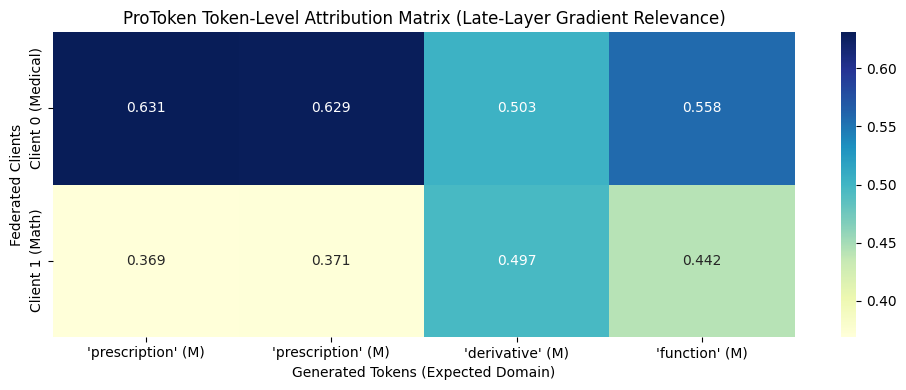

In [10]:
# Cell 6: Visualizing Token-Level Client Attribution
tokens_labels = [f"'{r['token'].strip()}' ({r['expected_domain'][0]})" for r in benchmark_results]
c0_scores = [r['attribution']['Client_0 (Medical)'] for r in benchmark_results]
c1_scores = [r['attribution']['Client_1 (Math)'] for r in benchmark_results]

matrix = np.array([c0_scores, c1_scores])

plt.figure(figsize=(10, 4))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=tokens_labels,
    yticklabels=["Client 0 (Medical)", "Client 1 (Math)"]
)
plt.title("ProToken Token-Level Attribution Matrix (Late-Layer Gradient Relevance)")
plt.xlabel("Generated Tokens (Expected Domain)")
plt.ylabel("Federated Clients")
plt.tight_layout()
plt.show()